# Problem Set 1: example solution

Computational Macro, HWS 2026

This notebook generalizes the value function iteration of session 2 to CRRA utility and partial depreciation. The derivations of Part 1 are in the written solution.

### 0. Packages

The first cell installs the packages of this notebook into the environment the notebook runs in
(the `compmacro` kernel, top right corner). Packages you already have are skipped, so the cell takes
a second. If it does install something, restart the kernel (the restart button at the top of the
notebook) and run the notebook from the top.

In [ ]:
# Installs the packages of this notebook into the environment of the running kernel.
# Packages you already have are skipped ("Requirement already satisfied").
%pip install "numpy==2.2.*" "matplotlib==3.10.*"

In [1]:
import time
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

## Setup

Compared to session 2 three things change (Question 2.1 a): the utility function, the resources $k^\alpha + (1-\delta)k$ and hence the matrices $C$ and $U$, and the steady state that sets the grid bounds. The rest of the loop is unchanged.

In [2]:
@dataclass(frozen=True)
class EconomicParameters:
    alpha: float = 0.3
    beta: float = 0.96
    gamma: float = 1.0
    delta: float = 1.0


@dataclass(frozen=True)
class NumericalParameters:
    nk: int = 200
    kmin_rel: float = 0.1
    kmax_rel: float = 2.0
    crit: float = 1e-6
    maxiter: int = 5000


def util(c, gamma):
    if gamma == 1.0:
        return np.log(c)
    return (c ** (1 - gamma) - 1) / (1 - gamma)


def resources(k, par):
    return k ** par.alpha + (1 - par.delta) * k


def steady_state(par):
    return (par.alpha / (1 / par.beta - 1 + par.delta)) ** (1 / (1 - par.alpha))

In [3]:
def solve_vfi(par, mpar):
    print(f"Value function iteration with parameters alpha = {par.alpha}, beta = {par.beta}, "
          f"gamma = {par.gamma}, delta = {par.delta}, N = {mpar.nk}, crit = {mpar.crit}")
    kstar = steady_state(par)
    k = np.linspace(mpar.kmin_rel * kstar, mpar.kmax_rel * kstar, mpar.nk)

    C = resources(k, par)[:, None] - k[None, :]      # rows: k_i, columns: k'_j
    U = np.full(C.shape, -np.inf)
    U[C > 0] = util(C[C > 0], par.gamma)

    v = np.zeros(mpar.nk)
    dist, it = np.inf, 0
    t0 = time.perf_counter()
    while dist > mpar.crit and it < mpar.maxiter:
        M = U + par.beta * v[None, :]
        vnew, g = M.max(axis=1), M.argmax(axis=1)
        dist = np.max(np.abs(vnew - v))
        v = vnew
        it += 1
    runtime = time.perf_counter() - t0
    if dist > mpar.crit:
        raise RuntimeError("VFI did not converge")

    print(f"  iterations: {it}, final distance: {dist:.2e}, "
          f"policy at lower bound: {np.sum(g == 0)}, at upper bound: {np.sum(g == mpar.nk - 1)}")
    c = resources(k, par) - k[g]
    return dict(k=k, v=v, g=g, c=c, it=it, time=runtime, kstar=kstar)


def euler_error(c, kprime, cnext, par):
    R = par.alpha * kprime ** (par.alpha - 1) + 1 - par.delta
    return 1 - (par.beta * R) ** (-1 / par.gamma) * cnext / c


def euler_error_grid(sol, par):
    # tomorrow's capital k_{g_i} is on the grid, so tomorrow's consumption is c_{g_i}
    k, g, c = sol["k"], sol["g"], sol["c"]
    return euler_error(c, k[g], c[g], par)


def simulate(sol, k0, T=300):
    idx = np.zeros(T + 1, dtype=int)
    idx[0] = np.argmin(np.abs(sol["k"] - k0))
    for t in range(T):
        idx[t + 1] = sol["g"][idx[t]]
    return sol["k"][idx]

## Question 2.1 (b)–(d): log utility and full depreciation

In [4]:
par = EconomicParameters()
mpar = NumericalParameters()
sol = solve_vfi(par, mpar)

# closed form
k = sol["k"]
F = par.alpha / (1 - par.alpha * par.beta)
E = (np.log(1 - par.alpha * par.beta) + par.beta * F * np.log(par.alpha * par.beta)) / (1 - par.beta)
kp_true = par.alpha * par.beta * k ** par.alpha
print(f"(b) policy error: {np.max(np.abs(k[sol['g']] - kp_true)):.2e}, "
      f"value error: {np.max(np.abs(sol['v'] - (E + F * np.log(k)))):.2e}")

# (c) test with the closed form policy
c_true = (1 - par.alpha * par.beta) * k ** par.alpha
cnext_true = (1 - par.alpha * par.beta) * kp_true ** par.alpha
print(f"(c) max |e| with closed form: {np.max(np.abs(euler_error(c_true, kp_true, cnext_true, par))):.1e}")

# (d) on-grid policy
e = euler_error_grid(sol, par)
i = np.argmax(np.abs(e))
print(f"(d) max |e| = {np.abs(e[i]):.2e} at grid point {i + 1}, k = {k[i]:.4f}")

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 1.0, delta = 1.0, N = 200, crit = 1e-06
  iterations: 337, final distance: 9.79e-07, policy at lower bound: 0, at upper bound: 0
(b) policy error: 9.39e-04, value error: 2.41e-05
(c) max |e| with closed form: 6.7e-16
(d) max |e| = 1.17e-02 at grid point 2, k = 0.0185

We reproduce the numbers from class (337 iterations, policy error $9.4 \cdot 10^{-4}$, value error $2.4 \cdot 10^{-5}$), and the Euler equation error of the closed form is zero up to floating point precision. For the grid solution, consumption at the second grid point $k = 0.0185$ deviates by 1.2 percent from what the Euler equation prescribes.

## Question 2.1 (e)–(f): $\gamma = 2$, $\delta = 0.1$

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 200, crit = 1e-06
  iterations: 226, final distance: 9.80e-07, policy at lower bound: 0, at upper bound: 0
(e) max |e| = 4.56e-02 at grid point 1, k = 0.2921, mean log10|e| = -2.16
(f) k* = 2.9208, grid points with k' = k: [2.8856 2.9135 2.9414]

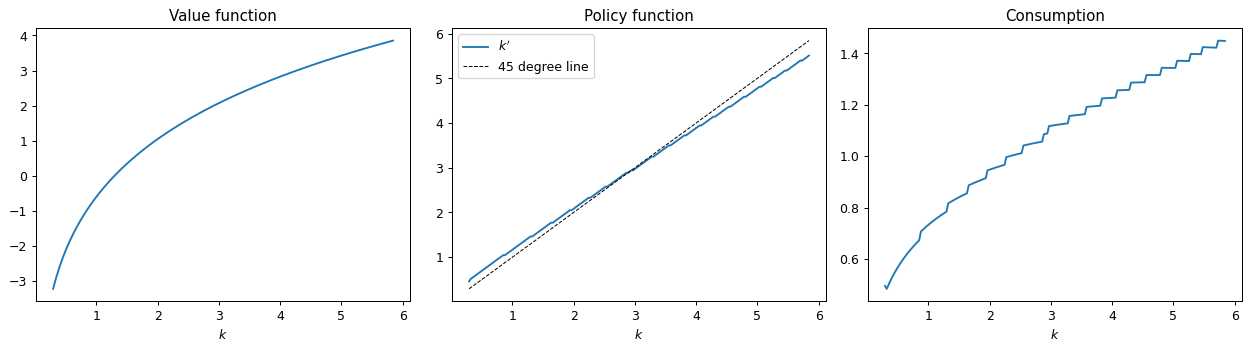

In [5]:
par2 = EconomicParameters(gamma=2.0, delta=0.1)
sol2 = solve_vfi(par2, mpar)
k2, g2 = sol2["k"], sol2["g"]
e2 = euler_error_grid(sol2, par2)
i = np.argmax(np.abs(e2))
print(f"(e) max |e| = {np.abs(e2[i]):.2e} at grid point {i + 1}, k = {k2[i]:.4f}, "
      f"mean log10|e| = {np.mean(np.log10(np.abs(e2))):.2f}")

fixed = k2[g2 == np.arange(mpar.nk)]
print(f"(f) k* = {sol2['kstar']:.4f}, grid points with k' = k: {np.round(fixed, 4)}")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(k2, sol2["v"])
ax[0].set_title("Value function")
ax[1].plot(k2, k2[g2], label="$k'$")
ax[1].plot(k2, k2, "k--", lw=0.8, label="45 degree line")
ax[1].set_title("Policy function")
ax[1].legend()
ax[2].plot(k2, sol2["c"])
ax[2].set_title("Consumption")
for a in ax:
    a.set_xlabel("$k$")
plt.tight_layout()
plt.show()

The largest Euler equation error is 4.6 percent of consumption, at the first grid point $k = 0.292$, and the mean of $\log_{10}|e_i|$ is $-2.16$. The policy crosses the 45 degree line in the three grid points around $k^* = 2.921$, so the two agree up to the grid spacing. The error is largest at low $k$, where consumption is smallest: the policy misses the exact choice by up to one grid spacing, and this error is measured relative to $c$.

## Question 2.2 (a): simulation

path settles at 2.8856, k* = 2.9208, difference -1.2 percent

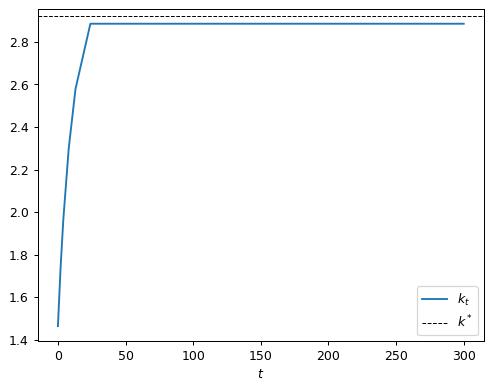

In [6]:
path = simulate(sol2, 0.5 * sol2["kstar"])
print(f"path settles at {path[-1]:.4f}, k* = {sol2['kstar']:.4f}, "
      f"difference {100 * (path[-1] / sol2['kstar'] - 1):.1f} percent")

plt.plot(path, label="$k_t$")
plt.axhline(sol2["kstar"], color="k", ls="--", lw=0.8, label="$k^*$")
plt.xlabel("$t$")
plt.legend()
plt.show()

The path settles at 2.886, 1.2 percent below $k^*$. It stops at the first grid point with $g_i = i$ it reaches from below.

## Question 2.2 (b)–(c): the cost of the grid

In [7]:
rows = []
for nk in [50, 200, 800]:
    s = solve_vfi(par2, NumericalParameters(nk=nk))
    rows.append((nk, s["k"][1] - s["k"][0], s["it"], s["time"],
                 np.max(np.abs(euler_error_grid(s, par2))), simulate(s, 0.5 * s["kstar"])[-1]))

print(f"\n{'N':>5} {'spacing':>8} {'iter':>5} {'time':>7} {'max|e|':>9} {'settles':>8}")
for r in rows:
    print(f"{r[0]:5d} {r[1]:8.4f} {r[2]:5d} {r[3]:7.3f} {r[4]:9.2e} {r[5]:8.4f}")

N_needed = 800 * rows[-1][4] / 1e-4
print(f"\n(c) N for max|e| < 1e-4: {N_needed:,.0f}, "
      f"time: {rows[-1][3] * (N_needed / 800) ** 2 / 60:.0f} minutes")

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 50, crit = 1e-06
  iterations: 230, final distance: 9.67e-07, policy at lower bound: 0, at upper bound: 0
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 200, crit = 1e-06
  iterations: 226, final distance: 9.80e-07, policy at lower bound: 0, at upper bound: 0
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 800, crit = 1e-06
  iterations: 226, final distance: 9.62e-07, policy at lower bound: 0, at upper bound: 0

    N  spacing  iter    time    max|e|  settles
   50   0.1133   230   0.003  1.65e-01   2.7837
  200   0.0279   226   0.015  4.56e-02   2.8856
  800   0.0069   226   0.275  1.11e-02   2.9106

(c) N for max|e| < 1e-4: 88,864, time: 57 minutes

The number of iterations does not depend on $N$, but each iteration works on an $N \times N$ matrix, so the run time is of order $N^2$ (factor of about 16 from 200 to 800). The maximum Euler error is proportional to the grid spacing and falls like $1/N$ (factor of about 4). To get it below $10^{-4}$ we would need about 89,000 grid points, which would take around an hour and 63 GB for a single matrix.

## Question 2.2 (d)–(e): risk aversion

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 1.0, delta = 0.1, N = 800, crit = 1e-06
  iterations: 156, final distance: 9.73e-07, policy at lower bound: 0, at upper bound: 0
  periods to within 5% of k*: 15, saving rate at k0: 0.316
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 800, crit = 1e-06
  iterations: 226, final distance: 9.62e-07, policy at lower bound: 0, at upper bound: 0
  periods to within 5% of k*: 22, saving rate at k0: 0.254
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 5.0, delta = 0.1, N = 800, crit = 1e-06
  iterations: 247, final distance: 9.66e-07, policy at lower bound: 0, at upper bound: 0
  periods to within 5% of k*: 37, saving rate at k0: 0.198

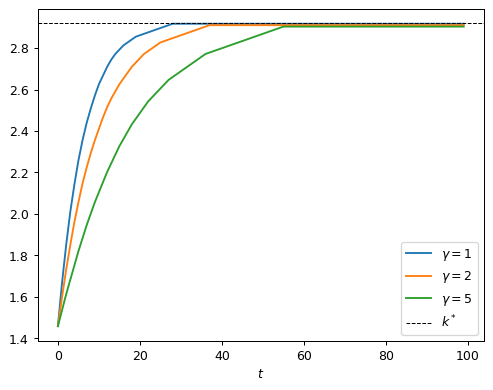

In [8]:
mpar800 = NumericalParameters(nk=800)
for gam in [1.0, 2.0, 5.0]:
    p = EconomicParameters(gamma=gam, delta=0.1)
    s = solve_vfi(p, mpar800)
    path = simulate(s, 0.5 * s["kstar"])
    t5 = np.argmax(np.abs(path - s["kstar"]) / s["kstar"] < 0.05)
    i0 = np.argmin(np.abs(s["k"] - 0.5 * s["kstar"]))
    k0 = s["k"][i0]
    srate = (s["k"][s["g"][i0]] - (1 - p.delta) * k0) / k0 ** p.alpha
    print(f"  periods to within 5% of k*: {t5}, saving rate at k0: {srate:.3f}")
    plt.plot(path[:100], label=f"$\\gamma = {gam:g}$")

plt.axhline(s["kstar"], color="k", ls="--", lw=0.8, label="$k^*$")
plt.xlabel("$t$")
plt.legend()
plt.show()

The household with $\gamma = 1$ reaches the steady state fastest (15 periods, against 22 for $\gamma = 2$ and 37 for $\gamma = 5$). At $k_0$ the return on capital is above $1/\beta$, so the household wants consumption to grow. With a high intertemporal elasticity of substitution $1/\gamma$ it accepts a steep consumption path and saves more (saving rate 0.316 against 0.198 for $\gamma = 5$), so capital accumulates faster. The steady state does not depend on $\gamma$.